In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Feature extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

#Model
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

#Evaluation
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

#Class imbalance
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')

In [19]:
df = pd.read_csv('../Data/cleaned_data.csv')

print('Shape:', df.shape)
print('Fraud %:', round(df['fraudulent'].mean() * 100, 2))

Shape: (17880, 8)
Fraud %: 4.84


In [4]:
#Split feature and target
X_text = df['cleaned_text'].fillna('')
y = df['fraudulent']

metadata_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'has_company_profile',
    'has_requirements',
    'has_benefits'
]
X_meta = df[metadata_cols].fillna(0).values

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(X_text)

X_combined = hstack([X_tfidf, csr_matrix(X_meta)])
print('Combined matrix:', X_combined.shape)

Combined matrix: (17880, 5006)


In [5]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape[0], 'rows')
print('Test set:', X_test.shape[0], 'rows')

Training set: 14304 rows
Test set: 3576 rows


In [ ]:
#Baseline SVM: no imbalance handling
svm_baseline = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, random_state=42),
    cv=3
)
svm_baseline.fit(X_train, y_train)

y_pred_svm_base = svm_baseline.predict(X_test)
y_prob_svm_base = svm_baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm_base,
                            target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_svm_base), 4))


              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
   Fraud (1)       0.97      0.79      0.87       173

    accuracy                           0.99      3576
   macro avg       0.98      0.89      0.93      3576
weighted avg       0.99      0.99      0.99      3576

AUC-ROC: 0.9895


In [7]:
#SVM with class weighting 
svm_weighted = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, random_state=42, class_weight='balanced'),
    cv=3
)
svm_weighted.fit(X_train, y_train)

y_pred_svm_wt = svm_weighted.predict(X_test)
y_prob_svm_wt = svm_weighted.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm_wt,
                            target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_svm_wt), 4))

              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
   Fraud (1)       0.95      0.78      0.86       173

    accuracy                           0.99      3576
   macro avg       0.97      0.89      0.93      3576
weighted avg       0.99      0.99      0.99      3576

AUC-ROC: 0.99


In [8]:
#SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('After SMOTE:', pd.Series(y_train_smote).value_counts().to_dict())

#Train SVM on the balanced data
svm_smote = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, random_state=42),
    cv=3
)
svm_smote.fit(X_train_smote, y_train_smote)

y_pred_svm_sm = svm_smote.predict(X_test)
y_prob_svm_sm = svm_smote.predict_proba(X_test)[:, 1]

print()
print(classification_report(y_test, y_pred_svm_sm,
                            target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_svm_sm), 4))

After SMOTE: {0: 13611, 1: 13611}

              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
   Fraud (1)       0.96      0.76      0.85       173

    accuracy                           0.99      3576
   macro avg       0.98      0.88      0.92      3576
weighted avg       0.99      0.99      0.99      3576

AUC-ROC: 0.9876


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, y_prob, name):
    return{
        'Model': name,
        'Accuracy %': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Fraud Precision %': round(precision_score(y_true, y_pred) * 100, 2),
        'Fraud Recall %': round(recall_score(y_true, y_pred) * 100, 2),
        'Fraud F1 %': round(f1_score(y_true, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_svm_base, y_prob_svm_base, 'SVM-Baseline'),
    get_metrics(y_test, y_pred_svm_wt, y_prob_svm_wt, 'SVM-Class Weighting'),
    get_metrics(y_test, y_pred_svm_sm, y_prob_svm_sm, 'SVM-SMOTE'),
])

print(results.to_string(index=False))
results.to_csv('../Output/svm_comparison.csv', index=False)

              Model  Accuracy %  Fraud Precision %  Fraud Recall %  Fraud F1 %  AUC-ROC
       SVM-Baseline       98.85              97.14           78.61       86.90   0.9895
SVM-Class Weighting       98.74              95.07           78.03       85.71   0.9900
          SVM-SMOTE       98.69              96.32           75.72       84.79   0.9876


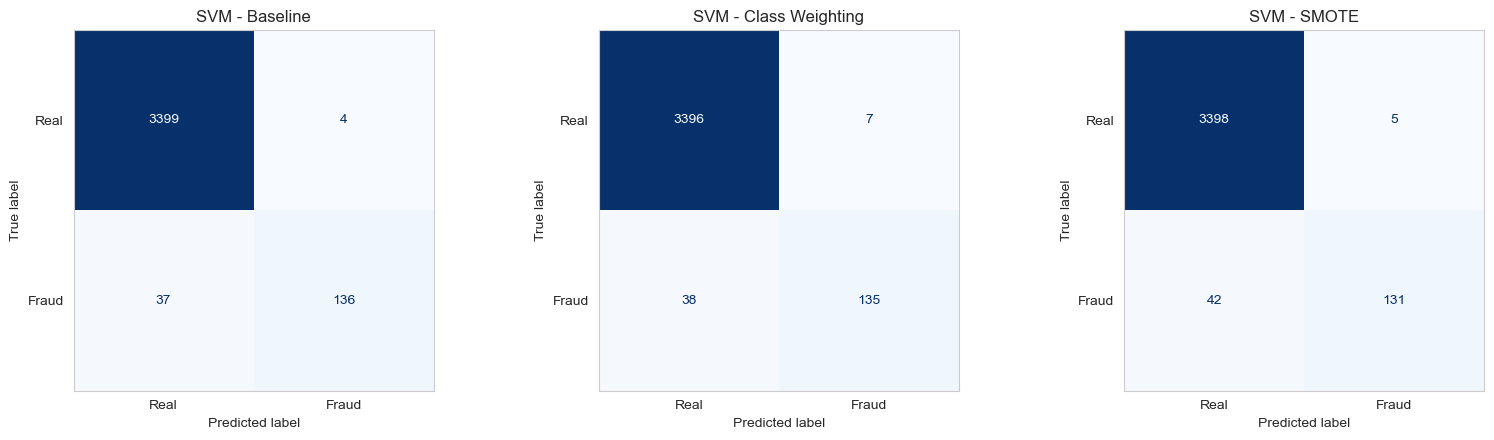

In [13]:
#Confusion matrices for the three svm 
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, preds, title in[
    (axes[0], y_pred_svm_base, 'Baseline'),
    (axes[1], y_pred_svm_wt, 'Class Weighting'),
    (axes[2], y_pred_svm_sm, 'SMOTE')
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Real', 'Fraud'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'SVM - {title}')
    ax.grid(False)
plt.tight_layout()
plt.savefig('../Output/21_svm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#Combine LR and SVM
lr_results = pd.read_csv('../Output/lr_comparison.csv')
svm_results = pd.read_csv('../Output/svm_comparison.csv')

final_results = pd.concat([lr_results, svm_results], ignore_index=True)

print(final_results.to_string(index=False))
final_results.to_csv('../Output/final_model_comparison.csv', index=False)

               Model  Accuracy %  Fraud Precision %  Fraud Recall %  Fraud F1 %  AUC-ROC
       LR - Baseline       97.26              98.70           43.93       60.80   0.9814
LR - Class Weighting       95.72              53.40           90.75       67.24   0.9887
          LR - SMOTE       97.18              65.13           89.60       75.43   0.9899
        SVM-Baseline       98.85              97.14           78.61       86.90   0.9895
 SVM-Class Weighting       98.74              95.07           78.03       85.71   0.9900
           SVM-SMOTE       98.69              96.32           75.72       84.79   0.9876


In [21]:
#Cross validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#LR class weighting
lr_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
scores_lr = cross_val_score(lr_cv, X_combined, y, cv=skf, scoring='f1')

#SVM baseline
svm_cv = CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42), cv=3)
scores_svm = cross_val_score(svm_cv, X_combined, y, cv=skf, scoring='f1')

print('5-fold cross validation (F1 on fraud class)')
print(f'LR class weighted: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})')
print(f'SVM baseline: {scores_svm.mean():.4f} (+/- {scores_svm.std():.4f})')


5-fold cross validation (F1 on fraud class)
LR class weighted: 0.6670 (+/- 0.0162)
SVM baseline: 0.8289 (+/- 0.0241)


---
## Findings

- SVM baseline is strong on its own - F1 87, only 4 false alarms, without any imbalance handling
- Class weighting and SMOTE barely changed SVM (F1 87 -> 86 -> 85) - completely different from LR where they were essential
- So imbalance handling is model-dependent: critical for LR, unnecessary for SVM
- Overall best F1: SVM baseline (87) vs best LR (SMOTE, 75.43)
- But LR class weighting still catches the most fraud (misses 16 vs SVM's 37) - recall vs precision trade-off to discuss
- 5-fold cross validation confirms stability - LR: 0.667(±0.016), SVM: 0.829 (±0.024). SVM's lead holds across all folds.